<a href="https://colab.research.google.com/github/HailemariamAdugnaw/AI/blob/computer-vision/CVimageclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

drive_path = '/content/drive/My Drive'

if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"'{drive_path}' does not exist. Ensure Google Drive is mounted correctly.")

Contents of '/content/drive/My Drive':
Programming.gdoc
database
oop
andemta
today files
networking
photo_2025-02-03_02-45-42.jpg
photo_2025-02-03_02-45-42.pdf
Java OOP Object Usage.gdoc
DSA
To represent the full complexity of a social netw... (1).gdoc
query optimization.gdoc
To represent the full complexity of a social netw....gdoc
Operational Plan.docx
Entereprenur.gdoc
,, .. 
gas station the best.gdoc
gas stations in gondar.gdoc
Hotel Database SQL Operations.gdoc
DELIMITER   
CREATE TRIGGER update_room_status_af... (1).gdoc
DELIMITER   
CREATE PROCEDURE make_reservation(....gdoc
DELIMITER   
CREATE PROCEDURE check_out_guest(IN....gdoc
DELIMITER   
CREATE PROCEDURE check_in_guest(IN r....gdoc
DELIMITER   
CREATE FUNCTION is_room_available(ro....gdoc
DELIMITER   
CREATE FUNCTION calculate_revenue(st....gdoc
DELIMITER   
CREATE TRIGGER calculate_service_cha....gdoc
DELIMITER   
CREATE TRIGGER update_room_status_af....gdoc
DELIMITER   
CREATE PROCEDURE add_guest(
    IN p....gdoc
CREATE

In [9]:
import zipfile
import os

zip_path = '/content/drive/My Drive/flowers.zip'
extract_path = '/content/flowers'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")

Dataset extracted to: /content/flowers


In [11]:
import os

flowers_path = '/content/flowers'

if os.path.exists(flowers_path):
    print(f"Contents of '{flowers_path}':")
    for item in os.listdir(flowers_path):
        print(item)
else:
    print(f"'{flowers_path}' does not exist. The extraction might have failed or the path is incorrect.")

Contents of '/content/flowers':
flowers


In [13]:
import os

nested_flowers_path = '/content/flowers/flowers'

if os.path.exists(nested_flowers_path):
    print(f"Contents of '{nested_flowers_path}':")
    for item in os.listdir(nested_flowers_path):
        print(item)
else:
    print(f"'{nested_flowers_path}' does not exist. Please check the extraction path.")

Contents of '/content/flowers/flowers':
tulip
dandelion
daisy
lily
orchid
sunflower
rose


In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

### Define Dataset Parameters

We need to define parameters like image height and width, batch size, and the path to our dataset.

In [15]:
img_height = 180
img_width = 180
batch_size = 32
data_dir = '/content/flowers/flowers' # The nested directory where flower categories are found

### Load and Preprocess the Dataset

We'll use `tf.keras.utils.image_dataset_from_directory` to efficiently load the images and automatically label them based on subdirectory names. We'll also split the data into training and validation sets.

In [16]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 7000 files belonging to 7 classes.
Using 5600 files for training.
Found 7000 files belonging to 7 classes.
Using 1400 files for validation.


In [17]:
class_names = train_ds.class_names
print(f"Class names: {class_names}")
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

Class names: ['daisy', 'dandelion', 'lily', 'orchid', 'rose', 'sunflower', 'tulip']
Number of classes: 7


### Configure Dataset for Performance

We'll use `AUTOTUNE` and `cache()` and `prefetch()` to optimize data loading performance.

In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Now that the data is loaded and prepared, we can define and build our CNN model.

In [19]:
model = keras.Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.compile(
  optimizer='adam',
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,543 (15.22 MB)

 Trainable params: 3,989,543 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
epochs = 10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.6384 - loss: 1.0107 - val_accuracy: 0.7593 - val_loss: 0.6891
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8102 - loss: 0.5456 - val_accuracy: 0.7993 - val_loss: 0.6062
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8923 - loss: 0.3232 - val_accuracy: 0.8271 - val_loss: 0.4912
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9416 - loss: 0.1779 - val_accuracy: 0.8393 - val_loss: 0.5045
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9705 - loss: 0.0984 - val_accuracy: 0.8271 - val_loss: 0.6398
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9827 - loss: 0.0557 - val_accuracy: 0.8300 - val_loss: 0.7106
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9843 - loss: 0.0541 - val_accuracy: 0.8164 - val_loss: 0.7928
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9934 - loss: 0.0240 - val_acc

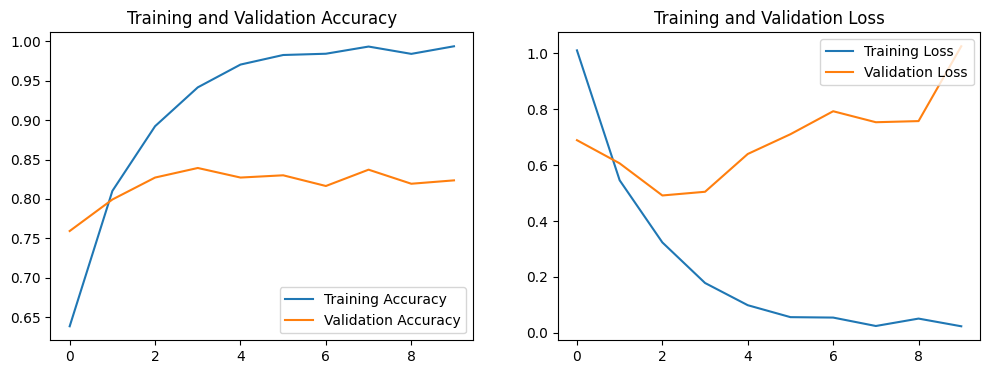

In [24]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2) # Corrected from (1, 1, 2) to (1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step


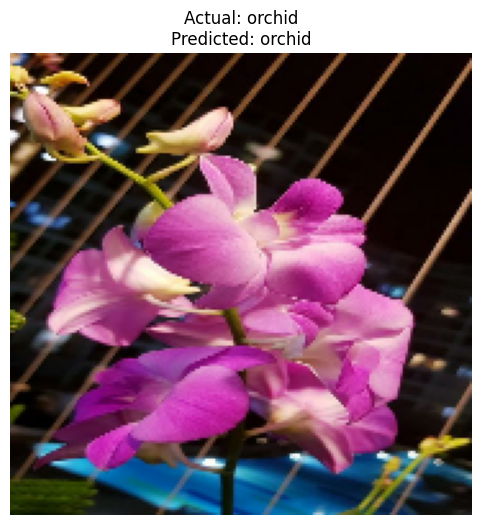

In [25]:
import numpy as np

# Get a batch of validation images and labels
image_batch, label_batch = next(iter(val_ds))

# Take the first image from the batch for prediction
sample_image = image_batch[0]
sample_label = label_batch[0].numpy()

# Preprocess the image for the model: add a batch dimension
img_array = tf.expand_dims(sample_image, 0)

# Make a prediction
predictions = model.predict(img_array)

# Get the predicted class (index with highest probability)
predicted_class_index = np.argmax(predictions[0])
predicted_class_name = class_names[predicted_class_index]
actual_class_name = class_names[sample_label]

# Display the image and prediction
plt.figure(figsize=(6, 6))
plt.imshow(sample_image.numpy().astype('uint8'))
plt.title(f"Actual: {actual_class_name}\nPredicted: {predicted_class_name}")
plt.axis('off')
plt.show()

### Test with a custom image
You can now test the model with your own image by providing its path.

Enter the path to your image: /content/flowers/flowers/lily/184961685_9a58a86de3_k.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


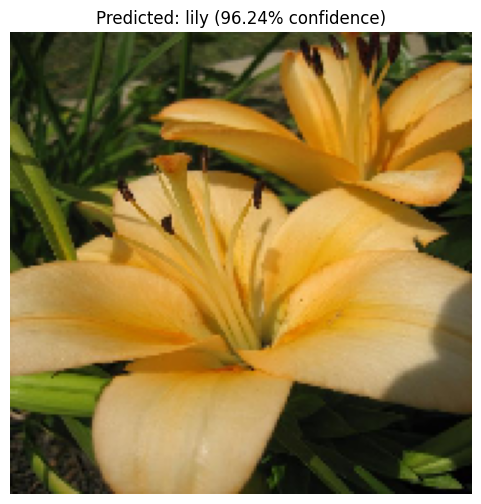

In [36]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Prompt user for image path
image_path = input("Enter the path to your image: ")

try:
    # Load the image
    img = image.load_img(image_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create a batch

    # Make prediction
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    predicted_class_name = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)

    # Display the image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f}% confidence)")
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"Error: The file at '{image_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")